In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
df=pd.read_csv("housing.csv")
df.head()
df=df[df['ocean_proximity']!="ISLAND"]

In [4]:
df.shape


(20635, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20635 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20635 non-null  float64
 1   latitude            20635 non-null  float64
 2   housing_median_age  20635 non-null  float64
 3   total_rooms         20635 non-null  float64
 4   total_bedrooms      20428 non-null  float64
 5   population          20635 non-null  float64
 6   households          20635 non-null  float64
 7   median_income       20635 non-null  float64
 8   median_house_value  20635 non-null  float64
 9   ocean_proximity     20635 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20635.000000,20635.000000,20635.000000,20635.000000,20428.000000,20635.000000,20635.000000,20635.000000,20635.000000
mean,-119.569999,35.632412,28.636152,2636.020208,537.899305,1425.660286,499.593700,3.870944,206813.756288
std,2.003685,2.135918,12.583924,2181.794772,421.425970,1132.530137,382.357072,1.899961,115372.499511
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1448.000000,296.000000,787.000000,280.000000,2.563100,119600.000000
50%,-118.500000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.535200,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743700,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
Name: count, dtype: int64

In [8]:
import seaborn as sns



In [9]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [10]:
df.dropna(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

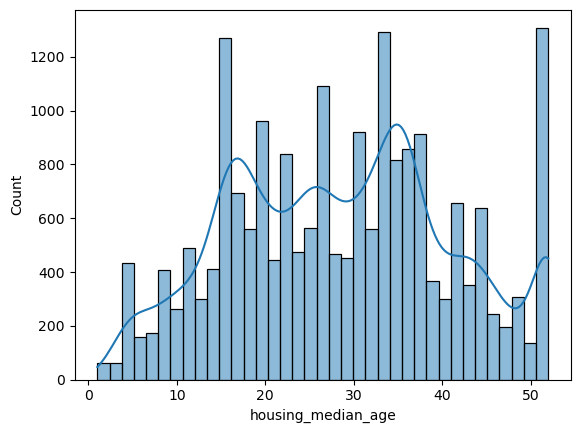

In [12]:
sns.histplot(x=df["housing_median_age"],kde=True)
plt.show()

In [13]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

<Axes: xlabel='ocean_proximity', ylabel='count'>

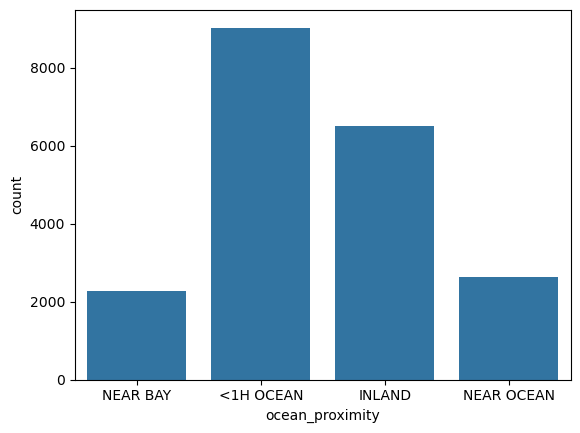

In [14]:
sns.countplot(x='ocean_proximity',data=df)

<Axes: xlabel='ocean_proximity'>

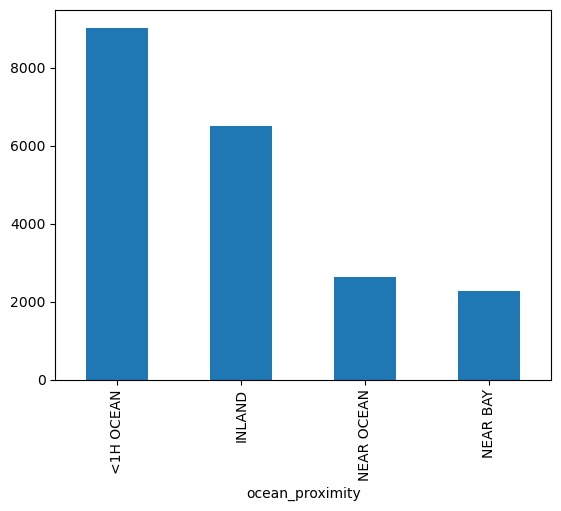

In [15]:
df['ocean_proximity'].value_counts().plot(kind='bar')

In [16]:
li=list(df.columns)

In [17]:
li

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity']

In [18]:
li=li[:-1]

In [19]:
li

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

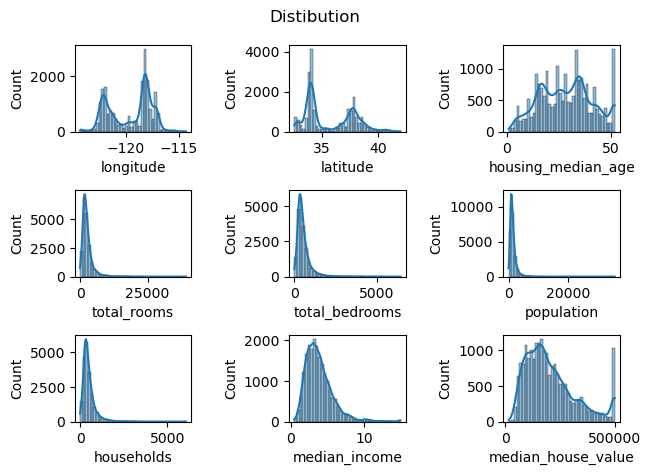

In [20]:
fig,axis=plt.subplots(nrows=3,ncols=3)
fig.suptitle("Distibution")
for i,col in enumerate(li):
    row=i//3
    coli=i%3
    ax=axis[row,coli]
    sns.histplot(data=df,x=col,kde=True,ax=ax,bins=40)
plt.tight_layout()
plt.show()


In [21]:
df.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924628,-0.109556,0.045555,0.069653,0.100380,0.056604,-0.015464,-0.045642
latitude,-0.924628,1.000000,0.012192,-0.036799,-0.067066,-0.109193,-0.071939,-0.079796,-0.144312
housing_median_age,-0.109556,0.012192,1.000000,-0.360634,-0.320486,-0.295715,-0.302714,-0.118191,0.106077
total_rooms,0.045555,-0.036799,-0.360634,1.000000,0.930382,0.857273,0.918987,0.197822,0.133516
total_bedrooms,0.069653,-0.067066,-0.320486,0.930382,1.000000,0.877758,0.979740,-0.007767,0.049792
population,0.100380,-0.109193,-0.295715,0.857273,0.877758,1.000000,0.907177,0.004989,-0.025069
households,0.056604,-0.071939,-0.302714,0.918987,0.979740,0.907177,1.000000,0.013350,0.065122
median_income,-0.015464,-0.079796,-0.118191,0.197822,-0.007767,0.004989,0.013350,1.000000,0.688848
median_house_value,-0.045642,-0.144312,0.106077,0.133516,0.049792,-0.025069,0.065122,0.688848,1.000000


<Axes: >

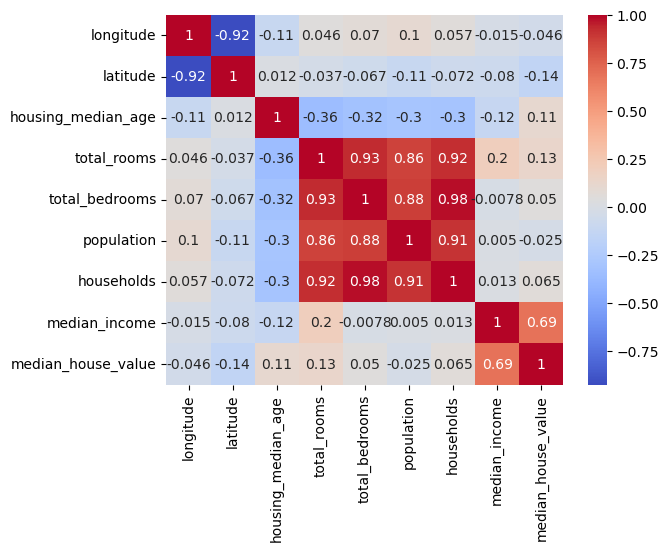

In [22]:
import seaborn as sns

corr = df.drop(['ocean_proximity'], axis=1).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

<Axes: xlabel='longitude', ylabel='median_house_value'>

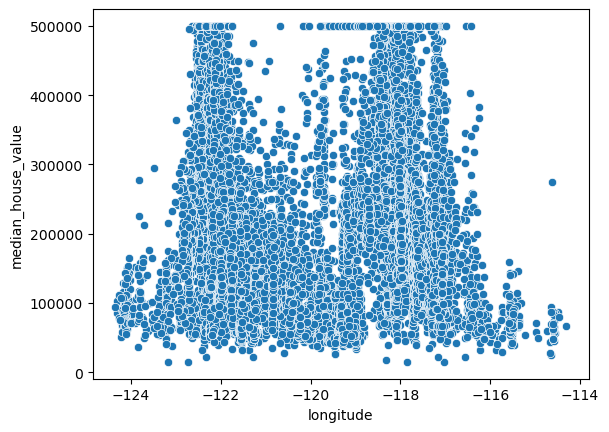

In [23]:
sns.scatterplot(x="longitude",y="median_house_value",data=df)

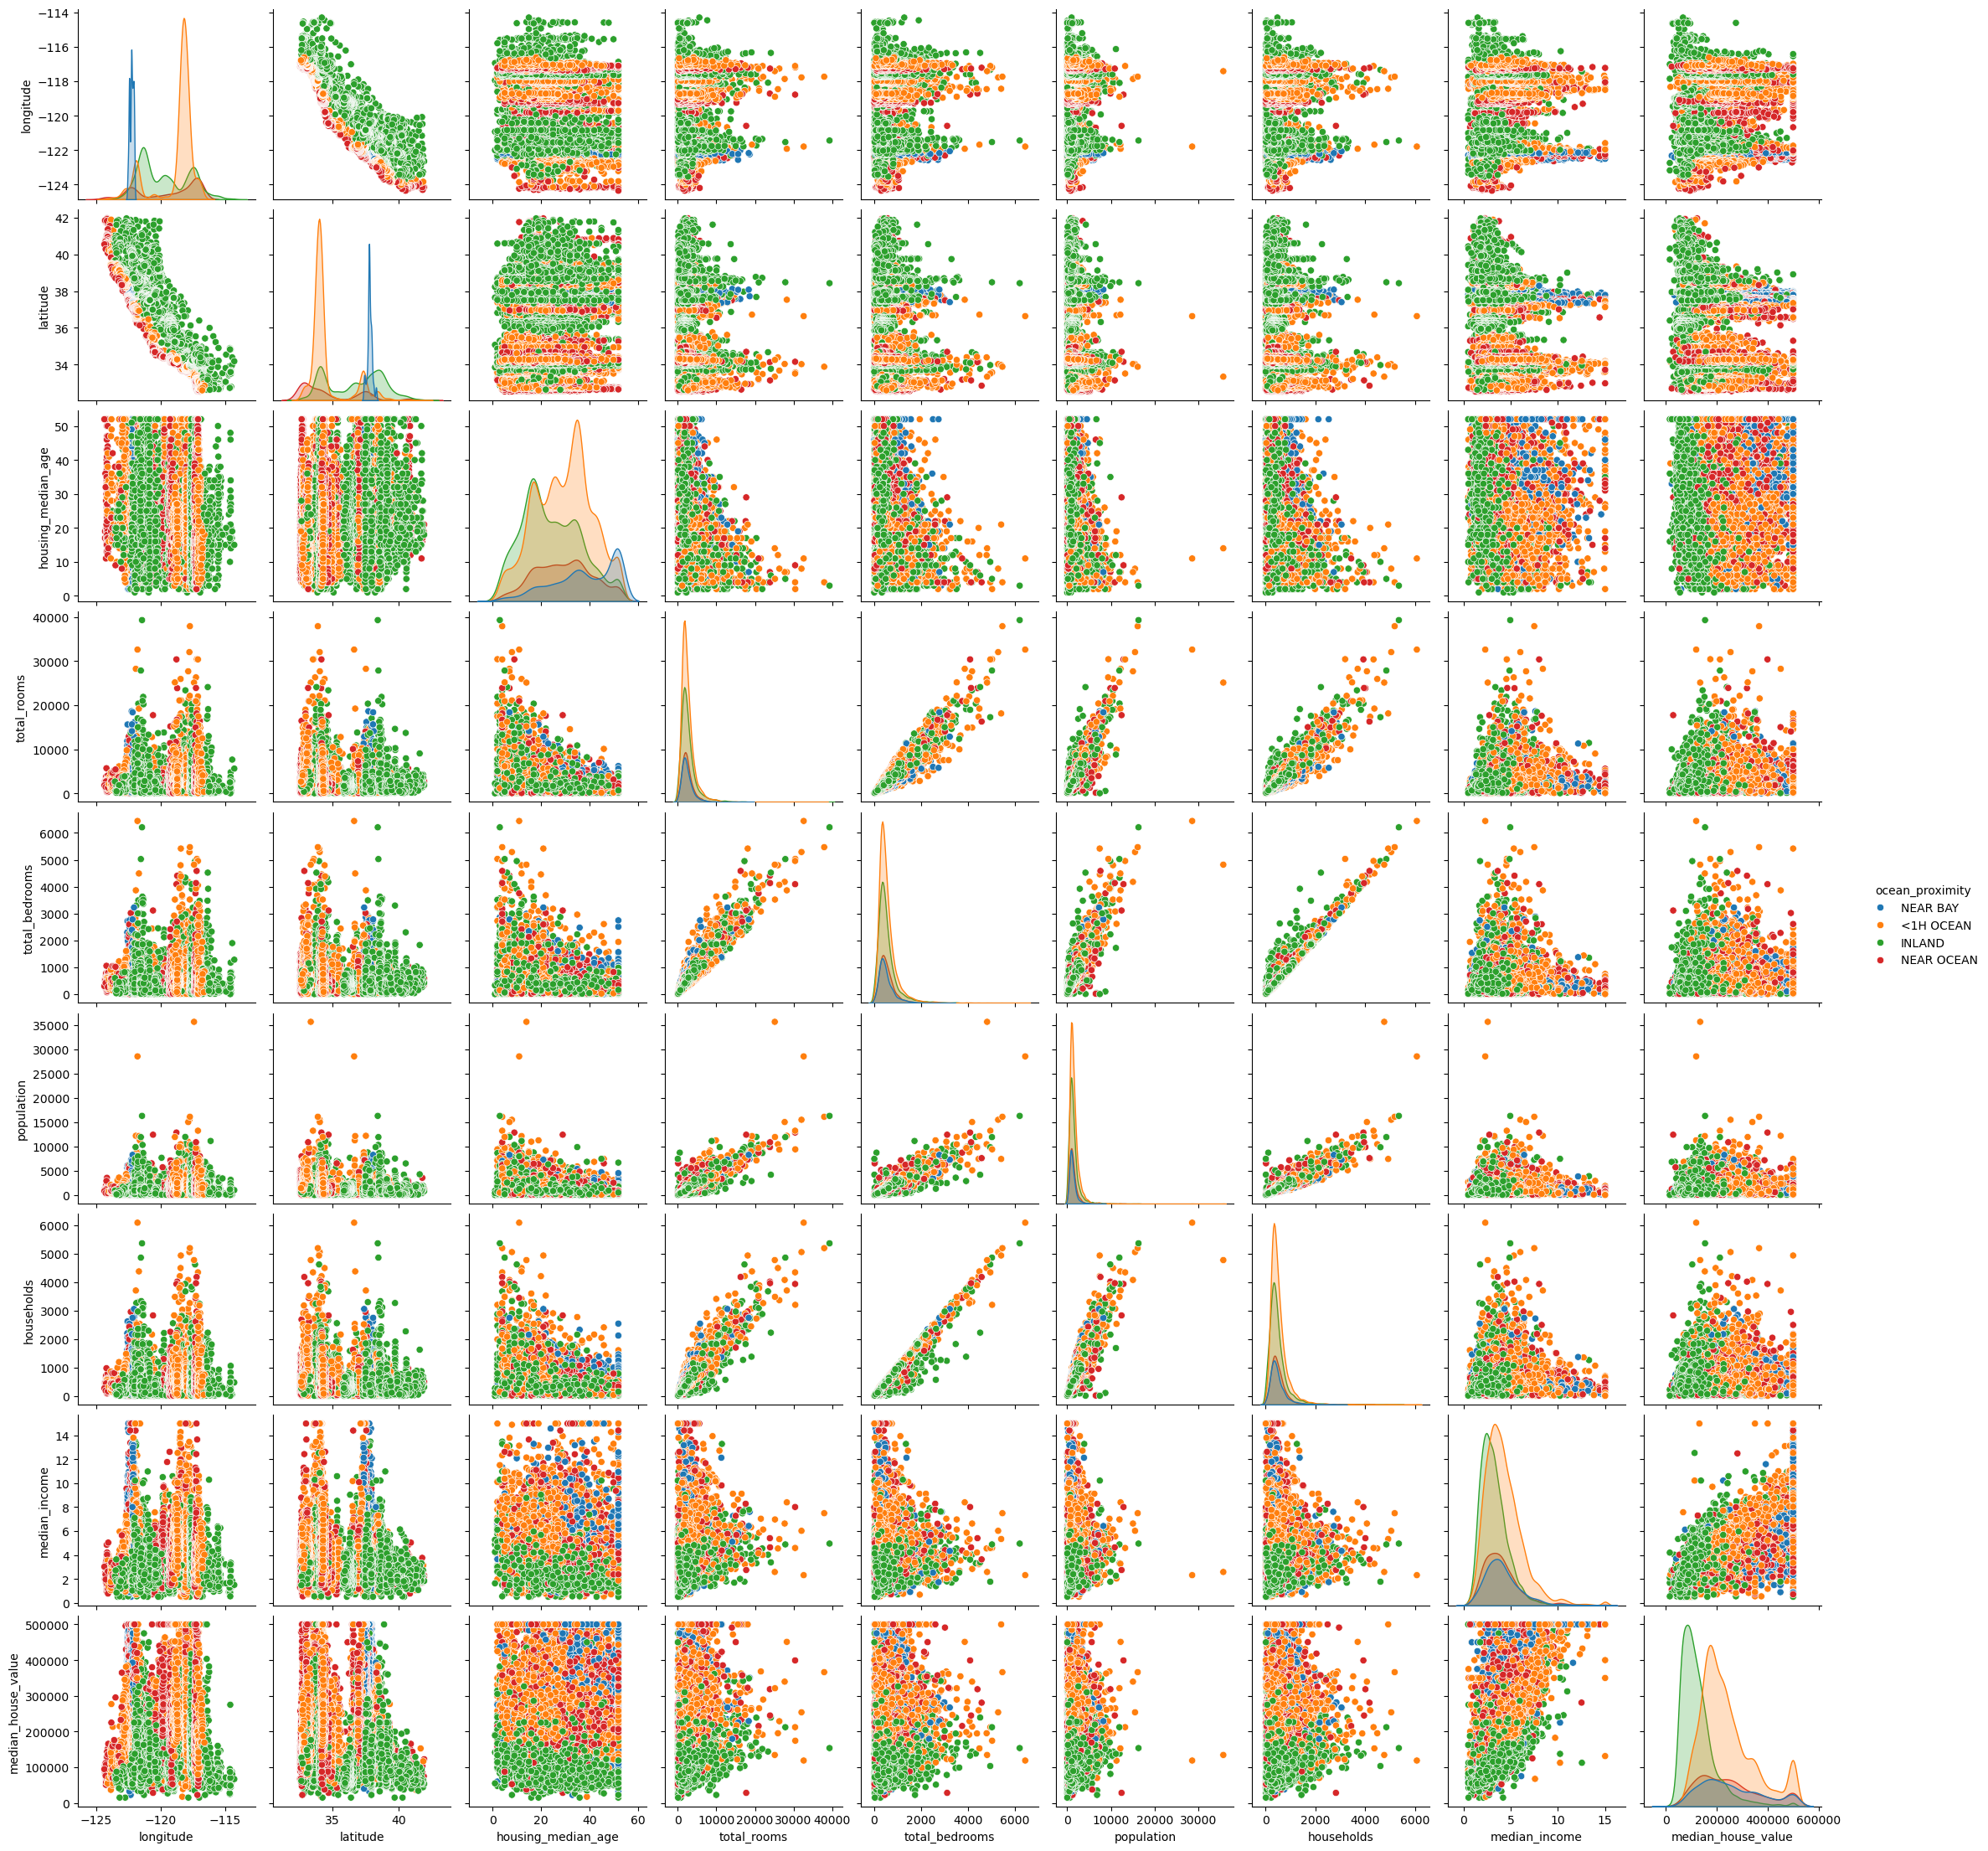

In [24]:
sns.pairplot(df,hue='ocean_proximity')

c:\Users\kanha\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


<Axes: >

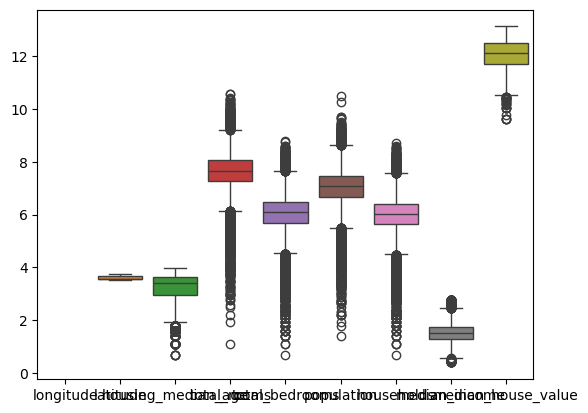

In [25]:
sns.boxplot(data=np.log1p(df[li]))

<Axes: xlabel='median_income', ylabel='median_house_value'>

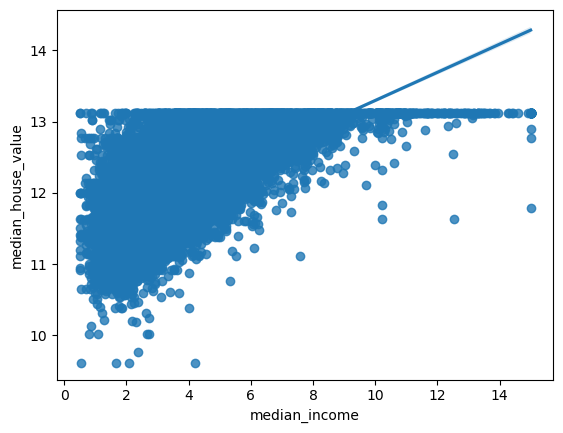

In [26]:
sns.regplot(x="median_income",y=np.log1p(df['median_house_value']),data=df)

<Axes: xlabel='ocean_proximity', ylabel='median_income'>

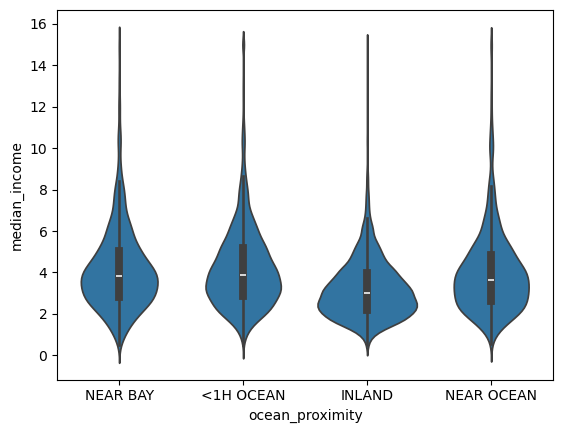

In [27]:
sns.violinplot(x='ocean_proximity', y='median_income', data=df)

In [28]:
for col in li:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

c:\Users\kanha\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


<Axes: >

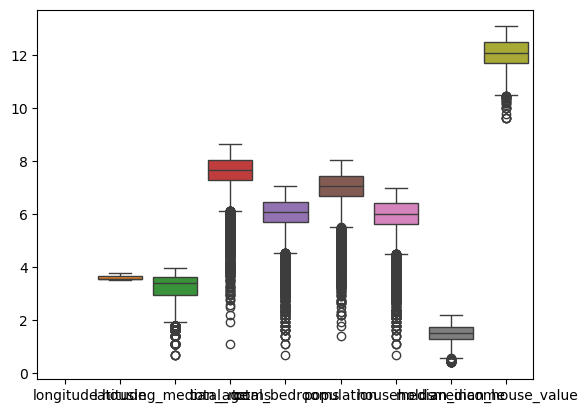

In [29]:
sns.boxplot(data=np.log1p(df[li]))

<Axes: xlabel='median_house_value'>

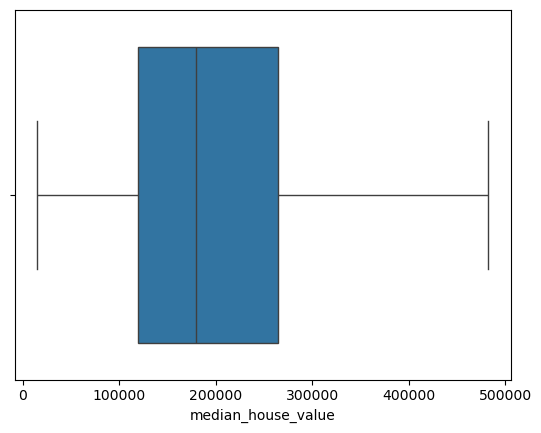

In [30]:
sns.boxplot(x=df['median_house_value'])

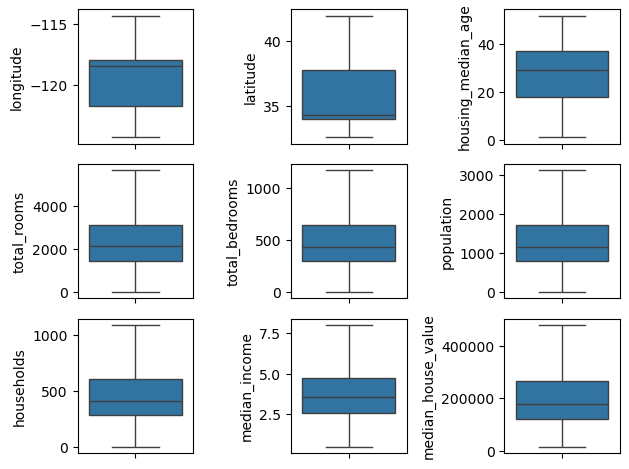

In [31]:
fig,axes=plt.subplots(nrows=3,ncols=3)
for i,col in enumerate(li):
    row=i//3
    ci=i%3
    ax=axes[row,ci]
    sns.boxplot(data=df[col],ax=ax)
plt.tight_layout()
plt.show()

<Axes: xlabel='longitude', ylabel='latitude'>

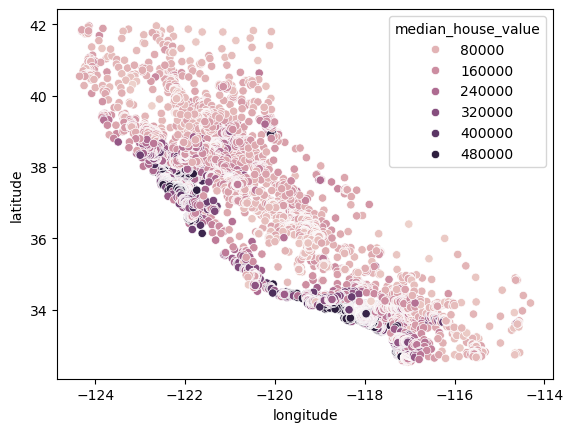

In [32]:
sns.scatterplot(x='longitude', y='latitude', hue='median_house_value', data=df)

In [33]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

In [34]:
df['rooms_per_household'] = df['total_rooms'] / df['households']

<Axes: xlabel='total_rooms', ylabel='median_house_value'>

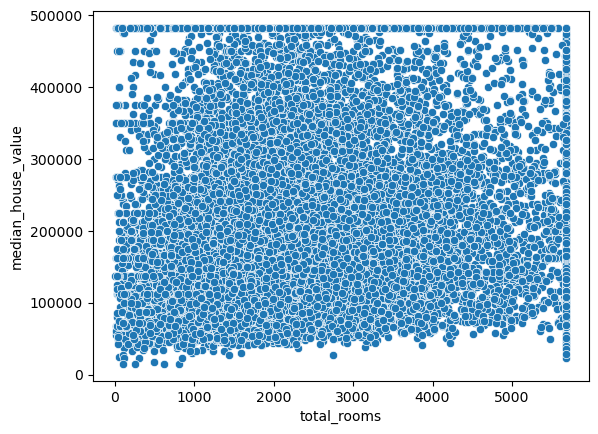

In [35]:
sns.scatterplot(x='total_rooms', y='median_house_value', data=df)

<Axes: xlabel='median_income', ylabel='Density'>

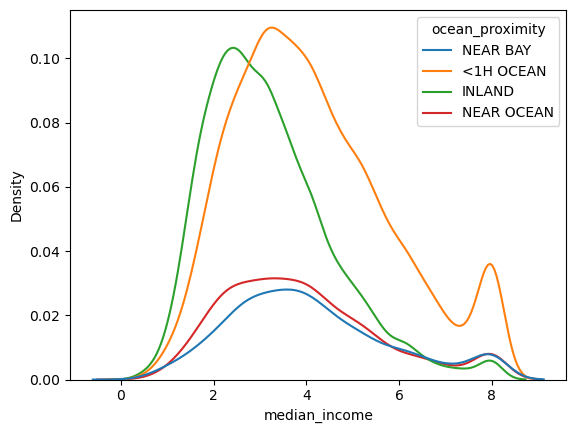

In [36]:
sns.kdeplot(data=df, x='median_income', hue='ocean_proximity')

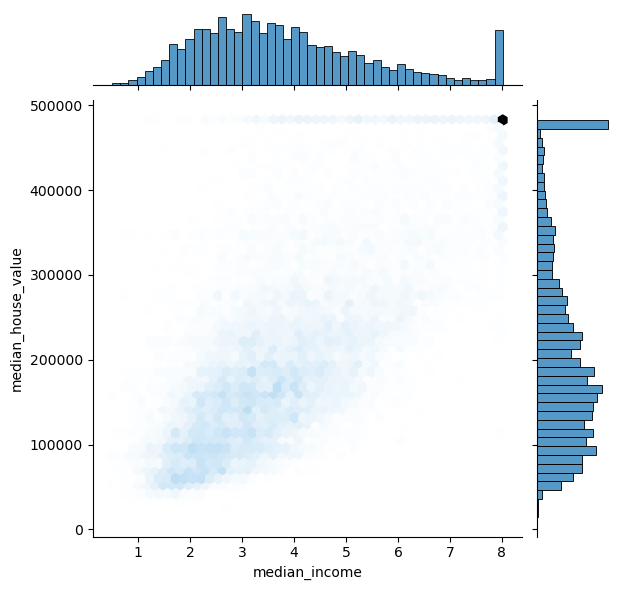

In [37]:
sns.jointplot(x='median_income', y='median_house_value', data=df, kind='hex')

<Axes: xlabel='housing_median_age', ylabel='median_house_value'>

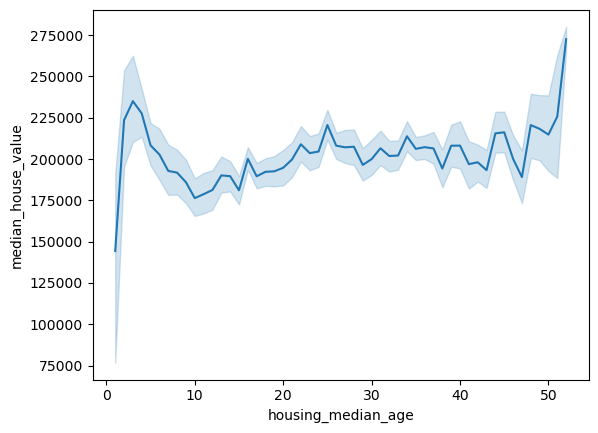

In [38]:
sns.lineplot(x='housing_median_age', y='median_house_value', data=df)

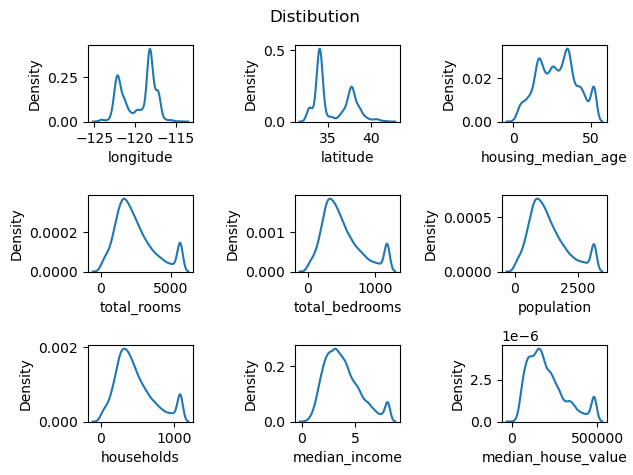

In [39]:
fig,axis=plt.subplots(nrows=3,ncols=3)
fig.suptitle("Distibution")
for i,col in enumerate(li):
    row=i//3
    coli=i%3
    ax=axis[row,coli]
    sns.kdeplot(data=df,x=col,ax=ax)
plt.tight_layout()
plt.show()

In [40]:
new_cols=list(df.columns)

In [41]:
new_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value',
 'ocean_proximity',
 'rooms_per_household']

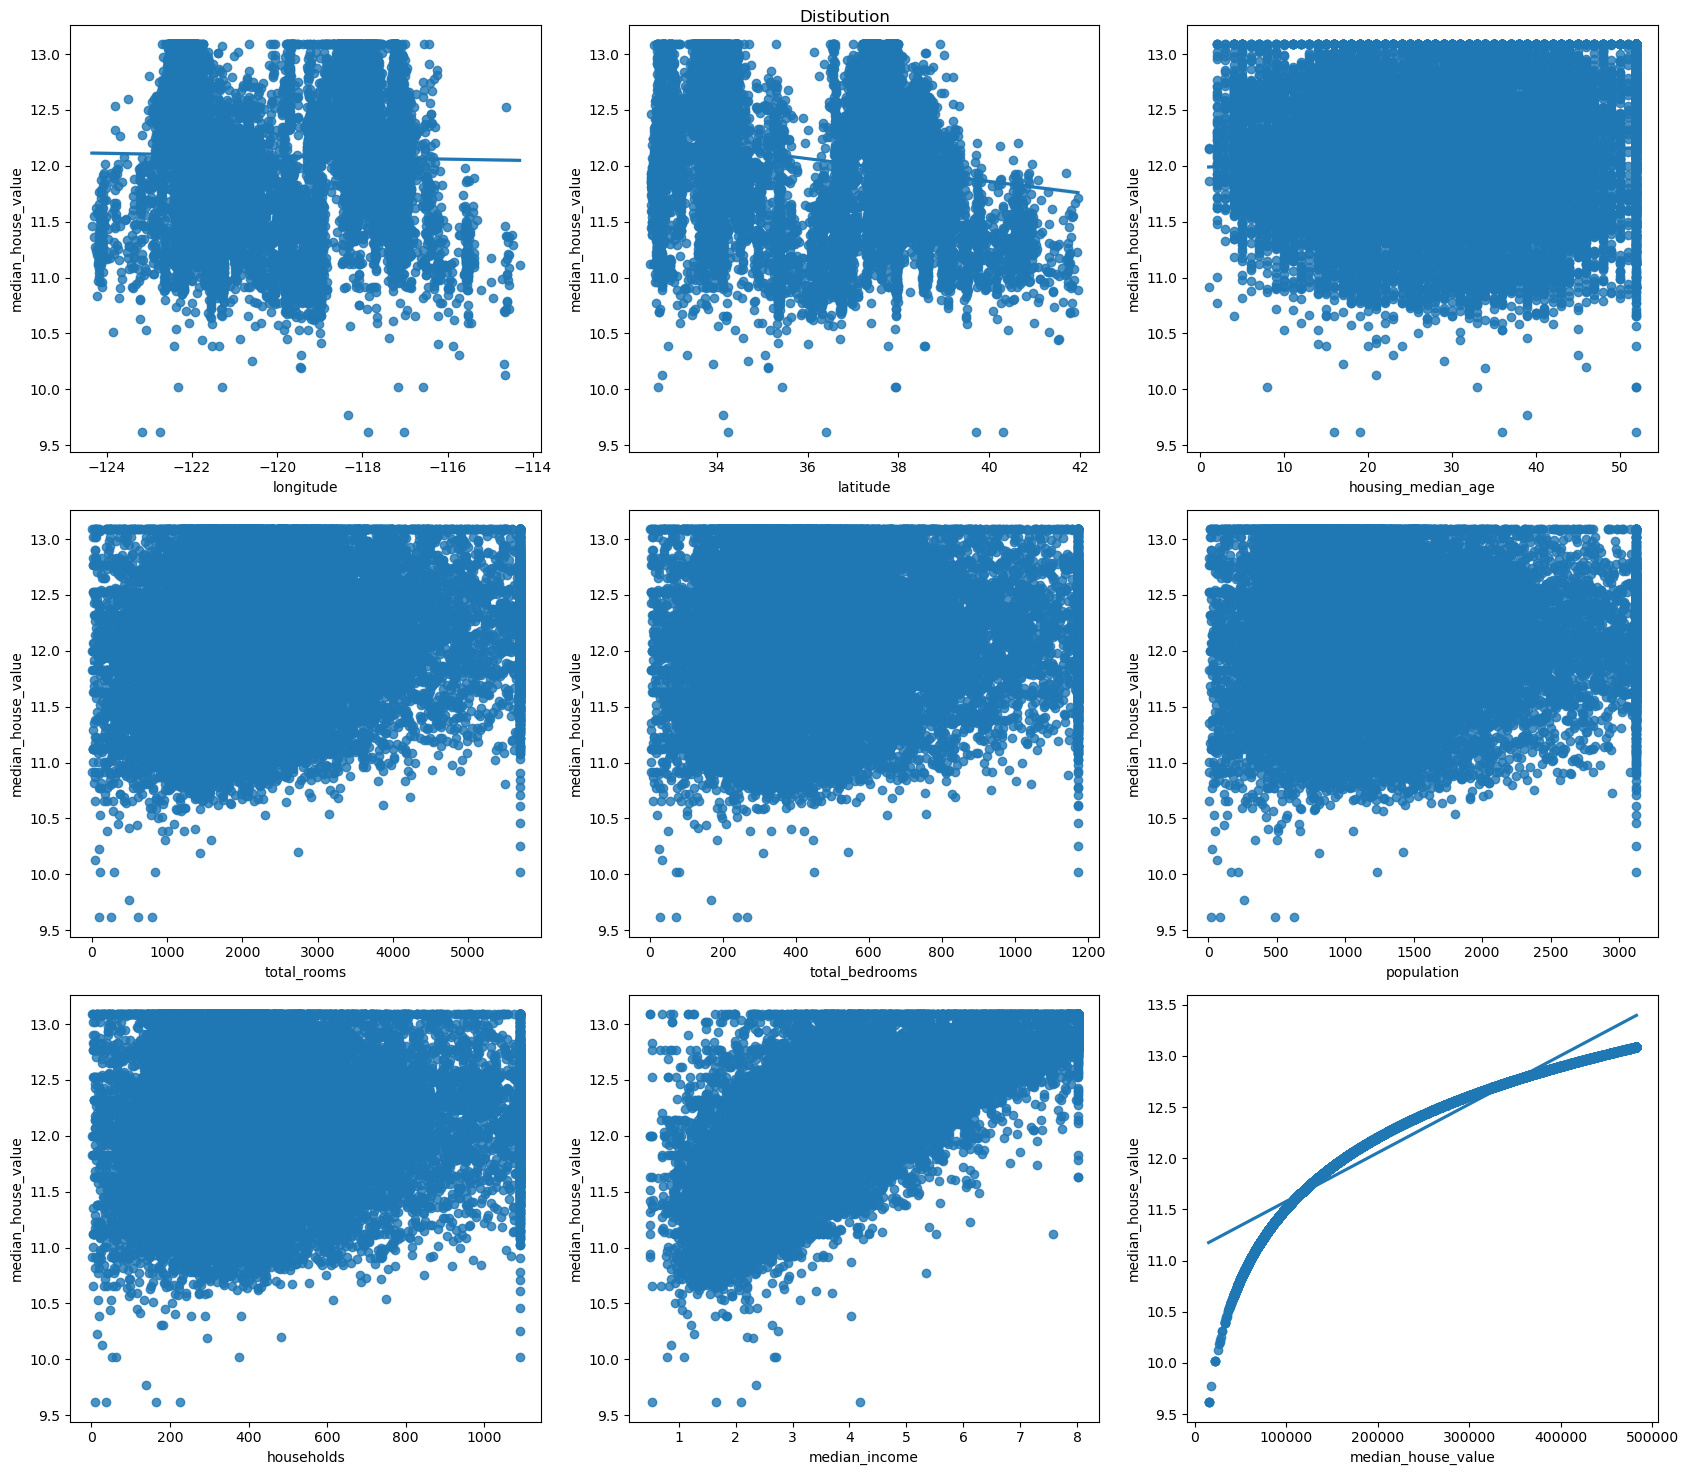

In [42]:
fig,axis=plt.subplots(nrows=3,ncols=3,figsize=(17,15))
fig.suptitle("Distibution")
for i,col in enumerate(li):
    row=i//3
    coli=i%3
    ax=axis[row,coli]
    sns.regplot(data=df,x=col,y=np.log1p(df["median_house_value"]),ax=ax)
plt.tight_layout()
plt.show()

In [43]:
li

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income',
 'median_house_value']

In [44]:
X=df.drop("median_house_value",axis=1)

In [45]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household
0,-122.23,37.88,41.0,880.000,129.0,322.0,126.0,8.015087,NEAR BAY,6.984127
1,-122.22,37.86,21.0,5683.125,1106.0,2401.0,1090.0,8.015087,NEAR BAY,5.213876
2,-122.24,37.85,52.0,1467.000,190.0,496.0,177.0,7.257400,NEAR BAY,8.288136
3,-122.25,37.85,52.0,1274.000,235.0,558.0,219.0,5.643100,NEAR BAY,5.817352
4,-122.25,37.85,52.0,1627.000,280.0,565.0,259.0,3.846200,NEAR BAY,6.281853


In [46]:
y=df["median_house_value"]


In [47]:
y


0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20428, dtype: float64

In [48]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)
y_train = y_train / 100000
y_test = y_test / 100000


In [63]:
x_train["ocean_proximity"]=lb.fit_transform(x_train['ocean_proximity'])
lb.transform(x_test['ocean_proximity'])


array([4, 1, 0, ..., 1, 1, 4])

In [64]:


num_cols = x_train.drop("ocean_proximity", axis=1).columns



x_train[num_cols] = sc.fit_transform(x_train[num_cols])
x_test[num_cols] = sc.transform(x_test[num_cols])

In [50]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
num_cols = x_train.drop("ocean_proximity", axis=1).columns
cat_cols = ["ocean_proximity"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)



In [75]:
%pip install catboost

  Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached catboost-1.2.10-cp313-cp313-win_amd64.whl (100.2 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)

   ---------------------------------------- 0/2 [graphviz]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- ------------------- 1/2 [catboost]
   -------------------- -----------

In [76]:
%pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 2.6 MB/s eta 0:00:39
    --------------------------------------- 1.8/101.7 MB 3.4 MB/s eta 0:00:30
   - -------------------------------------- 2.6/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 3.9/101.7 MB 4.2 MB/s eta 0:00:24
   -- ------------------------------------- 5.2/101.7 MB 4.6 MB/s eta 0:00:21
   -- ------------------------------------- 6.6/101.7 MB 4.8 MB/s eta 0:00:20
   -- ------------------------------------- 7.6/101.7 MB 5.0 MB/s eta 0:00:19
   --- ------------------------------------ 9.2/101.7 MB 5.1 MB/s eta 0:00:19
   ---- ----------------------------------- 10.5/101.7 MB 5.2 MB/s eta 0:00:18
   ---- -----

In [51]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error
models={
    "Linear regression":LinearRegression(),
    "Decision":DecisionTreeRegressor(),
    "Random_forest":RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42
),
    
    "xgb":XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
),
    "catboost":CatBoostRegressor(
          iterations=5000,
    learning_rate=0.05,
    depth=6,
    verbose=0
    )
}
results=[]
for name,model in models.items():
    pipe=Pipeline([
        ("preprocessing",preprocessor),
        ("model",model)
    ])
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        
    })
print(pd.DataFrame(results).sort_values(by="R2", ascending=False))

               Model        R2
4           catboost  0.859378
3                xgb  0.846511
2      Random_forest  0.818846
0  Linear regression  0.666895
1           Decision  0.653096


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for pytorch
Failed to build pytorch
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'pytorch' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pytorch'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
          exec(compile('''
          ~~~~^^^^^^^^^^^^
          # This is <pip-setuptools-caller> -- a caller that pip uses to run setup.py
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
          ...<32 lines>...
          exec(compile(setup_py_code, filename, "exec"))
   

In [166]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset


In [ ]:
torch.manual_seed(123)


In [168]:
class custom(Dataset):
    def __init__(self,x,y):
        self.x=torch.tensor(x,dtype=torch.float32)
        self.y=torch.tensor(y.values,dtype=torch.float32).view(-1,1)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, index):
        
        return self.x[index],self.y[index]

x_train=preprocessor.fit_transform(x_train)
x_test=preprocessor.transform(x_test)
train_dataset=custom(x_train,y_train)
test_dataset=custom(x_test,y_test)
train_loader=DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    pin_memory=True
)
test_loader=DataLoader(
    test_dataset,shuffle=False,batch_size=32
)

In [169]:
o=len(train_dataset)
print(o)

16346


In [170]:
import torch.nn as nn

class mymodel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),   
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model=mymodel(x_train.shape[1])

        

In [171]:
x_train.shape

(16346, 14)

In [174]:
criterion=nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs=100
from tqdm import tqdm
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in tqdm(train_loader):
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

100%|██████████| 511/511 [00:04<00:00, 120.14it/s]


Epoch 1, Loss: 0.3857


100%|██████████| 511/511 [00:03<00:00, 150.82it/s]


Epoch 2, Loss: 0.3759


100%|██████████| 511/511 [00:03<00:00, 150.37it/s]


...

Epoch 98, Loss: 0.2700


100%|██████████| 511/511 [00:09<00:00, 56.68it/s]


Epoch 99, Loss: 0.2689


100%|██████████| 511/511 [00:04<00:00, 105.77it/s]

Epoch 100, Loss: 0.2682


In [175]:
model.eval()

mymodel(
  (model): Sequential(
    (0): Linear(in_features=14, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [176]:
y_pred=[]
total_loss=0
with torch.no_grad():
    for x,y in tqdm(test_loader):
        pred=model(x)
        loss=criterion(pred,y)
        y_pred.append(pred)
        total_loss+=loss.item()

    print(f"Loss :{total_loss/len(test_loader)} ")
y_preds=torch.cat(y_pred).numpy()
from sklearn.metrics import r2_score
print("R2:",r2_score(y_test,y_preds))

100%|██████████| 128/128 [00:00<00:00, 792.45it/s]

Loss :0.2797252822201699 
R2: 0.7874999664646143
